
# SVM Pipeline (Notebook Version)

This notebook replicates the core steps from `torch_prep_kfold.py` **without** K-folds, focused on a clear, linear pipeline:

1. Load two CSVs and merge on a key.
2. Train/test split **by sequence** (regression).
3. Keep **last 100%** of rows per sequence (based on temporal order: sequence → run → frame/time if available).
4. Average numeric features in groups of `navg=20` **per sequence**.
5. Standardize features using **train mean/std** (label unaffected); apply the same transform to test.
6. Train a **SVM** and evaluate.
7. Save the fitted model & scaler.

> ⚙️ **You must configure the paths and column names in the first cell below.**


In [89]:
import os, sys, logging
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
from joblib import dump

from typing import Optional, List

In [90]:
# --- CONFIG ---
DATA_FEATURES_CSV = "rawdat.csv"          # computed/processed features
DATA_LABELS_CSV   = "exp_data_all.csv"    # experimental labels
OUTPUT_DIR        = "outputs"

# Column names (edit to match your files)
ID_COL     = "sequence"    # in BOTH CSVs
LABEL_COL  = "bind_avg"    # target
RUN_COL    = "run"         # optional temporal order column; set to None if not present
FRAME_COLS = []            # optional alternative time/order columns (first that exists will be used)

# Split / filtering / aggregation
TEST_SIZE     = 0.2          # fraction of unique sequences for test split
RANDOM_STATE  = 42
KEEP_LAST_PCT = 100.0        # keep last X% rows per sequence
NAVG          = 200           # average numeric features in chunks of N per sequence

# SVM (best regresssion params from your table)
SVM_PARAMS = dict(kernel="rbf", C=1.81, gamma=0.004, epsilon=0.1)

os.makedirs(OUTPUT_DIR, exist_ok=True)
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

from pprint import pprint
pprint({
    "features_csv": DATA_FEATURES_CSV,
    "labels_csv": DATA_LABELS_CSV,
    "id_col": ID_COL,
    "label_col": LABEL_COL,
    "run_col": RUN_COL,
    "test_size": TEST_SIZE,
    "keep_last_pct": KEEP_LAST_PCT,
    "navg": NAVG,
    "svm_params": SVM_PARAMS,
})

{'features_csv': 'rawdat.csv',
 'id_col': 'sequence',
 'keep_last_pct': 100.0,
 'label_col': 'bind_avg',
 'labels_csv': 'exp_data_all.csv',
 'navg': 200,
 'run_col': 'run',
 'svm_params': {'C': 1.81, 'epsilon': 0.1, 'gamma': 0.004, 'kernel': 'rbf'},
 'test_size': 0.2}


In [91]:
def load_csv(filename: str, usecols: Optional[List[str]] = None) -> pd.DataFrame:
    df = pd.read_csv(filename, usecols=usecols)
    logging.info(f"Loaded {filename}: shape={df.shape}")
    return df


def require_columns(df: pd.DataFrame, required: List[str]):
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns {missing}. Available: {df.columns.tolist()}")


def find_first_existing(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    for c in candidates:
        if c in df.columns:
            return c
    return None


def keep_last_n_percent(
    df_in: pd.DataFrame,
    seq_col: str,
    keep_percent: float,
    run_col: Optional[str] = None,
    frame_col: Optional[str] = None,
) -> pd.DataFrame:
    """
    Keep only the last 'keep_percent'% rows per sequence, ordered by run_col or frame_col if available.
    Matches Carmen’s behavior.
    """
    if keep_percent >= 100.0:
        return df_in.copy()

    order_col = None
    if run_col is not None and run_col in df_in.columns:
        order_col = run_col
    elif frame_col is not None and frame_col in df_in.columns:
        order_col = frame_col

    out = []
    for uid, g in df_in.groupby(seq_col, sort=False):
        if order_col is not None:
            g = g.sort_values(order_col, kind="mergesort")
        k = max(1, int(np.ceil(len(g) * (keep_percent / 100.0))))
        out.append(g.tail(k))
    return pd.concat(out, axis=0).reset_index(drop=True)


def average_in_chunks_per_sequence(
    df_in: pd.DataFrame,
    seq_col: str,
    chunk_size: int,
    label_col: str,
    non_numeric_keep: Optional[List[str]] = None,
    run_col: Optional[str] = None,
    frame_col: Optional[str] = None,
) -> pd.DataFrame:
    """
    Average numeric features in NAVG-sized chunks per sequence (keeps partial last chunk).
    Matches Carmen’s NAVG averaging logic.
    """
    if chunk_size <= 1:
        return df_in.copy()

    order_col = None
    if run_col is not None and run_col in df_in.columns:
        order_col = run_col
    elif frame_col is not None and frame_col in df_in.columns:
        order_col = frame_col

    parts = []
    for uid, g in df_in.groupby(seq_col, sort=False):
        if order_col is not None:
            g = g.sort_values(order_col, kind="mergesort")
        idx = np.arange(len(g))
        g = g.copy()
        g["__chunk__"] = idx // chunk_size

        agg = g.groupby("__chunk__", as_index=False).mean(numeric_only=True)
        agg[seq_col] = uid

        num_cols = agg.select_dtypes(include=[np.number]).columns.tolist()
        num_cols = [c for c in num_cols if c != label_col]
        agg = agg[[seq_col] + num_cols + [label_col]]
        parts.append(agg)

    out = pd.concat(parts, axis=0).reset_index(drop=True)
    return out


def standardize_train_test(X_train: pd.DataFrame, X_test: pd.DataFrame):
    """
    Fit StandardScaler on training data only, then transform both sets.
    """
    scaler = StandardScaler().fit(X_train)
    X_tr_s = scaler.transform(X_train)
    X_te_s = scaler.transform(X_test)
    return scaler, X_tr_s, X_te_s



## 1) Load CSVs and Merge
Both CSVs must contain the key column (`ID_COL`). The merged DataFrame must include the target (`LABEL_COL`).


In [92]:

feat_df = load_csv(DATA_FEATURES_CSV)
lab_df  = load_csv(DATA_LABELS_CSV)

require_columns(feat_df, [ID_COL])
require_columns(lab_df,  [ID_COL, LABEL_COL])

df = feat_df.merge(lab_df[[ID_COL, LABEL_COL]], on=ID_COL, how="inner")
logging.info(f"Merged shape: {df.shape}")
display(df.head())


INFO: Loaded rawdat.csv: shape=(272160, 10)
INFO: Loaded exp_data_all.csv: shape=(168, 4)
INFO: Merged shape: (68040, 11)


,sequence,run,VDWAALS,EEL,EGB,ESURF,HB Energy,Hydrophobic Energy,Pi-Pi Energy,Delta_Entropy,bind_avg
0,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-236.997,-1869.660,1823.216,-35.292,-2.590101,-156.445725,-4.282747,-24.750849,0.166339
1,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-218.620,-1850.331,1807.831,-32.521,-2.977171,-142.709472,-7.240534,-25.235404,0.166339
2,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-232.611,-1878.075,1834.181,-34.170,-3.105868,-145.088977,-8.856276,-25.124940,0.166339
3,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-203.677,-1870.595,1823.641,-32.402,-3.414769,-150.961716,-5.338670,-23.079573,0.166339
4,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-212.279,-1864.730,1820.462,-31.858,-3.571942,-146.583284,-7.171679,-22.812241,0.166339


Deterministic ordering (do this before the split)

In [93]:
# Ensure identical row order across machines before splitting by groups
df = df.sort_values([ID_COL]).reset_index(drop=True)

RANDOM_STATE = 42



## 2) Train/Test Split by Sequence
We split on **unique sequences** to avoid leakage (all rows of a given sequence go to either train or test).


In [94]:

# Unique sequence ids for grouping
seq_ids = df[ID_COL].values

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, groups=seq_ids))

df_train = df.iloc[train_idx].copy()
df_test  = df.iloc[test_idx].copy()

logging.info(f"Train shape: {df_train.shape} | Test shape: {df_test.shape}")


INFO: Train shape: (53460, 11) | Test shape: (14580, 11)



## 3) Keep Last X% per Sequence
Temporal ordering uses `ID_COL → RUN_COL → first existing FRAME_COL` (if present). If no temporal column is found, current order is used.


In [95]:

# frame_col = find_first_existing(df, FRAME_COLS)
# logging.info(f"Temporal columns: run={RUN_COL if RUN_COL in df.columns else None}, frame={frame_col}")

# df_train_f = keep_last_n_percent(df_train, seq_col=ID_COL, keep_percent=KEEP_LAST_PCT,
#                                  run_col=RUN_COL if RUN_COL in df.columns else None,
#                                  frame_col=frame_col)
# df_test_f  = keep_last_n_percent(df_test,  seq_col=ID_COL, keep_percent=KEEP_LAST_PCT,
#                                  run_col=RUN_COL if RUN_COL in df.columns else None,
#                                  frame_col=frame_col)

# logging.info(f"After keep_last {KEEP_LAST_PCT}% -> Train: {df_train_f.shape} | Test: {df_test_f.shape}")



## 4) Average Numeric Columns in Chunks of `navg=20` per Sequence
We average **numeric features** (and label if numeric) in non-overlapping windows. Partial trailing windows are dropped to keep shapes consistent.


In [96]:

# # Choose non-numeric columns you want to preserve per chunk (optional)
# NON_NUMERIC_KEEP = [ID_COL, RUN_COL] if RUN_COL in df.columns else [ID_COL]

# df_train_avg = average_in_chunks_per_sequence(df_train_f, seq_col=ID_COL, chunk_size=NAVG,
#                                               label_col=LABEL_COL, non_numeric_keep=NON_NUMERIC_KEEP)
# df_test_avg  = average_in_chunks_per_sequence(df_test_f,  seq_col=ID_COL, chunk_size=NAVG,
#                                               label_col=LABEL_COL, non_numeric_keep=NON_NUMERIC_KEEP)

# # df_train_avg = df_train.groupby("sequence", as_index=False).mean(numeric_only=True)
# # df_test_avg  = df_test.groupby("sequence", as_index=False).mean(numeric_only=True)


# logging.info(f"Averaged -> Train: {df_train_avg.shape} | Test: {df_test_avg.shape}")
# display(df_train_avg.head())


In [97]:
df_train_f = keep_last_n_percent(df_train, seq_col=ID_COL, keep_percent=KEEP_LAST_PCT,
                                 run_col=RUN_COL if RUN_COL in df.columns else None,
                                 frame_col=frame_col)

df_test_f  = keep_last_n_percent(df_test,  seq_col=ID_COL, keep_percent=KEEP_LAST_PCT,
                                 run_col=RUN_COL if RUN_COL in df.columns else None,
                                 frame_col=frame_col)

# NAVG=20 averaging BEFORE training (Carmen’s data-prep convention)
df_train_avg = average_in_chunks_per_sequence(df_train_f, seq_col=ID_COL, chunk_size=NAVG,
                                              label_col=LABEL_COL, non_numeric_keep=[ID_COL],
                                              run_col=RUN_COL if RUN_COL in df.columns else None,
                                              frame_col=frame_col)

df_test_avg  = average_in_chunks_per_sequence(df_test_f,  seq_col=ID_COL, chunk_size=NAVG,
                                              label_col=LABEL_COL, non_numeric_keep=[ID_COL],
                                              run_col=RUN_COL if RUN_COL in df.columns else None,
                                              frame_col=frame_col)



## 5) Standardize Features (Train Mean/Std) — Label Unchanged
We compute mean/std on **train** features only, then transform both train and test for unbiased evaluation.


In [98]:

# # Build X, y
# def split_X_y(df_xy: pd.DataFrame, label_col: str):
#     require_columns(df_xy, [label_col])
#     y = df_xy[label_col].copy()
#     # Drop non-feature columns: label + sequence + any obvious meta columns
#     drop_cols = {label_col, ID_COL, "_chunk"}
#     if RUN_COL in df_xy.columns:
#         drop_cols.add(RUN_COL)
#     # Remove non-numeric columns from features automatically
#     X = df_xy.drop(columns=list(drop_cols), errors="ignore")
#     X = X.select_dtypes(include=[np.number])
#     return X, y

# X_train, y_train = split_X_y(df_train_avg, LABEL_COL)
# X_test,  y_test  = split_X_y(df_test_avg,  LABEL_COL)

# logging.info(f"Feature shapes -> X_train: {X_train.shape}, X_test: {X_test.shape}")

# scaler, X_train_s, X_test_s = standardize_train_test(X_train, X_test)


In [99]:
X_train, y_train = split_X_y(df_train_avg, LABEL_COL)
X_test,  y_test  = split_X_y(df_test_avg,  LABEL_COL)

scaler, X_train_s, X_test_s = standardize_train_test(X_train, X_test)  # fit on train only



## 6) Train SVM regressor and save artifacts


In [100]:
# Best SVM regression params from your table
svm = SVR(kernel="rbf", C=1.81, gamma=0.004, epsilon=0.1)

# Fit on standardized training features (you already computed X_train_s, X_test_s)
svm.fit(X_train_s, y_train)

# Row-level predictions
yhat_tr_row = svm.predict(X_train_s)
yhat_te_row = svm.predict(X_test_s)

# Save BOTH the scaler and the model so inference later is consistent
artifacts_path = os.path.join(OUTPUT_DIR, "svm_reg_artifacts.joblib")
dump({"scaler": scaler, "model": svm, "feature_cols": X_train.columns.tolist()}, artifacts_path)
artifacts_path

'outputs/svm_reg_artifacts.joblib'

In [119]:
print(len(yhat_te_row))
print(len(yhat_tr_row))

81
297


In [120]:
print(yhat_te_row)

[-0.36751649 -0.26454955 -0.35738469 -0.19142202 -0.21909006 -0.21267173
 -0.31776311 -0.23434847 -0.4048931  -0.00886014  0.11854629 -0.12157811
  0.06092016  0.15995499  0.04229159  0.10585512  0.05518358 -0.23671639
  0.20175942  0.24723317  0.46385456  0.53250675  0.53030653  0.23660537
  0.40847719  0.41294876  0.4400323   0.40130406  0.32598134  0.28048448
  0.24891839  0.38037076  0.15147833  0.26696531  0.13137301  0.22508073
 -0.17238395 -0.31602177 -0.27970172 -0.33809797 -0.11544199 -0.17526669
 -0.26272704 -0.08806913 -0.28893745 -0.14943202 -0.04187169 -0.16452492
  0.03202874  0.07839961 -0.17087559 -0.1224353  -0.04289862 -0.23014392
  0.60683599  0.53725858  0.41881319  0.52436018  0.43314043  0.49498716
  0.44559085  0.57870528  0.5264919   0.10540518  0.08854472  0.24457021
  0.37727895  0.27265919  0.20465526  0.26947334  0.22572366 -0.08179722
 -0.11154875 -0.31569137 -0.1381564  -0.32765631 -0.18030655 -0.19904193
 -0.3631436  -0.11870385 -0.02492777]



## 7) Metrics helpers (row level + sequence level, like Carmen’s aggregation)


In [122]:
from sklearn.metrics import mean_squared_error, accuracy_score
from scipy.stats import pearsonr

DATA_SCALE = "log"   # set to "nonlog" if Carmen used non-log data
THR = 0.0 if DATA_SCALE == "log" else 1.0

# def seq_aggregate(y_true, y_pred, seq_ids):
#     d = {}
#     for t, p, s in zip(y_true, y_pred, seq_ids):
#         d.setdefault(s, {"t": [], "p": []})
#         d[s]["t"].append(float(t)); d[s]["p"].append(float(p))
#     out = pd.DataFrame({
#         "sequence": list(d.keys()),
#         "y_true":   [np.mean(v["t"]) for v in d.values()],
#         "y_pred":   [np.mean(v["p"]) for v in d.values()],
#     })
#     return out

# te_seq_df = seq_aggregate(y_test.values, yhat_te_row, df_test_avg[ID_COL].values)

# mse = mean_squared_error(te_seq_df["y_true"], te_seq_df["y_pred"])
# pcc = pearsonr(te_seq_df["y_true"], te_seq_df["y_pred"])[0] if len(te_seq_df) > 1 else np.nan
# acc = accuracy_score((te_seq_df["y_true"] > THR).astype(int),
#                      (te_seq_df["y_pred"] > THR).astype(int))
# print({"MSE": mse, "PCC": pcc, "Accuracy": acc})


mse = mean_squared_error(y_train, yhat_tr_row)

print({"MSE": mse})


{'MSE': 0.6288736126919878}


In [114]:
print(te_seq_df)


                               sequence    y_true    y_pred
0  ACCAAAAAAAAAAAAAAAAAAAAAACTCATCCCCAA  0.180426 -0.285515
1  CACTCCACTCCAGTTCACTCTATTCAGTTCCACTCC -0.731150  0.019511
2  CCCCGCACCCACACGCGCGTGGAAGGGCCTGGATTC  0.829319  0.385969
3  CTGCGCAATACGCGGCACGCGCCAGGCCAAAGACTA  0.023120  0.267995
4  GAGAATGGGGTGAACCCGGGAGGCGGAGCTTGCAGT -0.791245 -0.226294
5  GAGGAAGCAGCCCTCGCCCCTGTCGGTGGAAAGAAG -0.458634 -0.090195
6  GCGGGGTGGAGCGAGCACGCGGGCGGGGCGGGGCGG  1.350172  0.507354
7  GGAAGCTGTGAAATCCGCGTGCACACCCATCCCAAA  0.445550  0.189613
8  TGTGGAGCAAGGGAGACAGAAGCTCATTGGCTAGAG -0.722719 -0.197686


In [115]:
print(len(te_seq_df))

9


Debugging:
print the inputs and outputs

In [102]:
# from sklearn.metrics import mean_squared_error, accuracy_score
# from scipy.stats import pearsonr
# import numpy as np
# import pandas as pd

# def compute_metrics(y_true, y_pred, ids=None, data_scale="log"):
#     """
#     Compute MSE, Pearson Correlation (PCC), and Accuracy.
#     - For regression: threshold predictions → classification for Accuracy.
#     - If ids are provided: aggregates by sequence (mean per sequence).
#     """
#     if ids is not None:
#         # Aggregate by sequence ID
#         agg_true, agg_pred = [], []
#         for uid in np.unique(ids):
#             mask = np.array(ids) == uid
#             agg_true.append(np.mean(np.array(y_true)[mask]))
#             agg_pred.append(np.mean(np.array(y_pred)[mask]))
#         y_true, y_pred = np.array(agg_true), np.array(agg_pred)

#     # MSE
#     mse = mean_squared_error(y_true, y_pred)

#     # Pearson correlation coefficient (PCC)
#     pcc = np.nan
#     if len(y_true) > 1:
#         pcc, _ = pearsonr(y_true, y_pred)

#     # Accuracy: threshold-based classification from regression
#     thr = 0.0 if data_scale == "log" else 1.0
#     y_true_cls = (y_true > thr).astype(int)
#     y_pred_cls = (y_pred > thr).astype(int)
#     acc = accuracy_score(y_true_cls, y_pred_cls)

#     return dict(MSE=mse, PCC=pcc, Accuracy=acc)


In [103]:
# # Row-level metrics
# row_metrics = compute_metrics(y_test, yhat_te_row)
# print("Row-level metrics:", row_metrics)

# # Sequence-level metrics (averaged per sequence ID)
# seq_metrics = compute_metrics(y_test, yhat_te_row, ids=df_test_avg[ID_COL].values)
# print("Sequence-level metrics:", seq_metrics)


In [104]:
'''
# Row-level predictions CSVs
pd.DataFrame({
    "sequence": df_train_avg[ID_COL].values,
    "y_true":   y_train,
    "y_pred":   yhat_tr_row
}).to_csv(os.path.join(OUTPUT_DIR, "svm_reg_train_row_preds.csv"), index=False)

pd.DataFrame({
    "sequence": df_test_avg[ID_COL].values,
    "y_true":   y_test,
    "y_pred":   yhat_te_row
}).to_csv(os.path.join(OUTPUT_DIR, "svm_reg_test_row_preds.csv"), index=False)

# Sequence-level averaged CSV (matches Carmen’s aggregation idea)
tr_seq_df.to_csv(os.path.join(OUTPUT_DIR, "svm_reg_train_seqavg.csv"), index=False)
te_seq_df.to_csv(os.path.join(OUTPUT_DIR, "svm_reg_test_seqavg.csv"),  index=False)

'''

'\n# Row-level predictions CSVs\npd.DataFrame({\n    "sequence": df_train_avg[ID_COL].values,\n    "y_true":   y_train,\n    "y_pred":   yhat_tr_row\n}).to_csv(os.path.join(OUTPUT_DIR, "svm_reg_train_row_preds.csv"), index=False)\n\npd.DataFrame({\n    "sequence": df_test_avg[ID_COL].values,\n    "y_true":   y_test,\n    "y_pred":   yhat_te_row\n}).to_csv(os.path.join(OUTPUT_DIR, "svm_reg_test_row_preds.csv"), index=False)\n\n# Sequence-level averaged CSV (matches Carmen’s aggregation idea)\ntr_seq_df.to_csv(os.path.join(OUTPUT_DIR, "svm_reg_train_seqavg.csv"), index=False)\nte_seq_df.to_csv(os.path.join(OUTPUT_DIR, "svm_reg_test_seqavg.csv"),  index=False)\n\n'

In [105]:
print("After NAVG shapes:", df_train_avg.shape, df_test_avg.shape)
print("Unique sequences in TEST:", te_seq_df.shape[0])
print("TEST sequence IDs:", sorted(te_seq_df["sequence"].tolist()))

After NAVG shapes: (297, 12) (81, 12)
Unique sequences in TEST: 9
TEST sequence IDs: ['ACCAAAAAAAAAAAAAAAAAAAAAACTCATCCCCAA', 'CACTCCACTCCAGTTCACTCTATTCAGTTCCACTCC', 'CCCCGCACCCACACGCGCGTGGAAGGGCCTGGATTC', 'CTGCGCAATACGCGGCACGCGCCAGGCCAAAGACTA', 'GAGAATGGGGTGAACCCGGGAGGCGGAGCTTGCAGT', 'GAGGAAGCAGCCCTCGCCCCTGTCGGTGGAAAGAAG', 'GCGGGGTGGAGCGAGCACGCGGGCGGGGCGGGGCGG', 'GGAAGCTGTGAAATCCGCGTGCACACCCATCCCAAA', 'TGTGGAGCAAGGGAGACAGAAGCTCATTGGCTAGAG']


## Now for cross validation

In [106]:
DATA_SCALE = "log"      # use "nonlog" if you know Carmen used non-log
THR = 0.0 if DATA_SCALE == "log" else 1.0

def seq_aggregate(y_true, y_pred, seq_ids):
    """Average per sequence (Carmen’s convention)."""
    d = {}
    for t, p, s in zip(y_true, y_pred, seq_ids):
        d.setdefault(s, {"t": [], "p": []})
        d[s]["t"].append(float(t)); d[s]["p"].append(float(p))
    return pd.DataFrame({
        "sequence": list(d.keys()),
        "y_true":   [np.mean(v["t"]) for v in d.values()],
        "y_pred":   [np.mean(v["p"]) for v in d.values()],
    })

def metrics_seq_level(y_true_seq, y_pred_seq):
    mse = mean_squared_error(y_true_seq, y_pred_seq)
    pcc = pearsonr(y_true_seq, y_pred_seq)[0] if len(y_true_seq) > 1 else np.nan
    acc = accuracy_score((y_true_seq > THR).astype(int),
                         (y_pred_seq > THR).astype(int))
    return {"MSE": mse, "PCC": pcc, "ACC": acc}

def plot_carmen_panel(y_true_seq, y_pred_seq, title, box_text=None):
    """Quadrants, y=x dotted, title, and a small metrics box."""
    x, y = np.asarray(y_true_seq), np.asarray(y_pred_seq)
    xmin, xmax = x.min()-0.1, x.max()+0.1
    ymin, ymax = y.min()-0.1, y.max()+0.1
    lo = min(xmin, ymin); hi = max(xmax, ymax)

    fig, ax = plt.subplots()
    # background quadrants
    ax.axvspan(lo, THR, ymin=0, ymax=0.5, facecolor="#f4b6b6", alpha=0.6)  # left-bottom
    ax.axvspan(THR, hi, ymin=0.5, ymax=1, facecolor="#cbe7c3", alpha=0.6)  # right-top
    ax.axhspan(lo, THR, xmin=0, xmax=0.5, facecolor="#f4b6b6", alpha=0.6)
    ax.axhspan(THR, hi, xmin=0.5, xmax=1, facecolor="#cbe7c3", alpha=0.6)

    # points + guides
    ax.scatter(x, y, alpha=0.8)
    ax.plot([lo, hi], [lo, hi], ls="--", color="gray", lw=1)
    ax.axvline(THR, color="gray", ls=":")
    ax.axhline(THR, color="gray", ls=":")

    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.set_title(title)

    if box_text:
        ax.text(0.97, 0.03, box_text, transform=ax.transAxes, ha="right", va="bottom",
                bbox=dict(facecolor="white", edgecolor="gray", alpha=0.8))
    plt.show()


### 2) 5-fold GroupKFold CV on the training set (OOF predictions)

Fold 1: {'MSE': 0.6611293933351658, 'PCC': 0.2634282235896111, 'ACC': 0.8571428571428571}
Fold 2: {'MSE': 1.2914033331834969, 'PCC': -0.6649277281525713, 'ACC': 0.42857142857142855}
Fold 3: {'MSE': 0.7911173692011975, 'PCC': 0.33938932710924014, 'ACC': 0.2857142857142857}
Fold 4: {'MSE': 0.5614450931226842, 'PCC': 0.6920243931586999, 'ACC': 0.8333333333333334}
Fold 5: {'MSE': 0.38826169607533484, 'PCC': 0.5415635496353244, 'ACC': 0.6666666666666666}
CV (seq-level) mean±std: {'MSE': '0.74 (0.34)', 'PCC': '0.23 (0.53)', 'ACC': '0.61 (0.25)'}


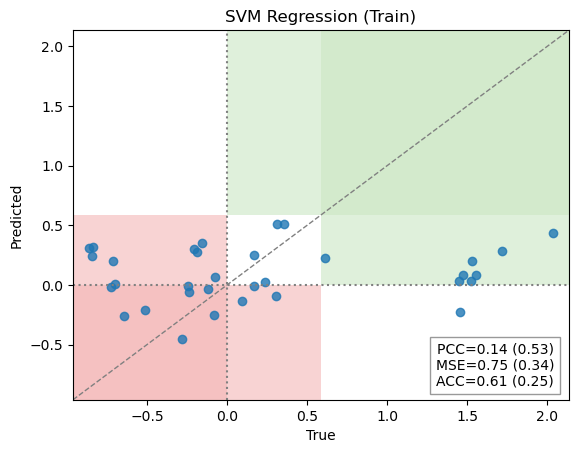

In [107]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

groups_tr = df_train_avg[ID_COL].values
Xtr_raw = X_train.values   # raw, unscaled; we’ll scale inside each fold
ytr     = y_train.values

gkf = GroupKFold(n_splits=5)

# storage for OOF predictions (row-level), and fold metrics
oof_pred = np.empty_like(ytr, dtype=float)
fold_metrics = []

for fold, (tr_idx, va_idx) in enumerate(gkf.split(Xtr_raw, ytr, groups=groups_tr), 1):
    X_tr, X_va = Xtr_raw[tr_idx], Xtr_raw[va_idx]
    y_tr, y_va = ytr[tr_idx],     ytr[va_idx]
    g_va       = groups_tr[va_idx]

    # fit scaler on fold-train only
    sc = StandardScaler().fit(X_tr)
    X_tr_s = sc.transform(X_tr)
    X_va_s = sc.transform(X_va)

    # train SVR (use your best params)
    svr = SVR(kernel="rbf", C=1.81, gamma=0.004, epsilon=0.1)
    svr.fit(X_tr_s, y_tr)

    # validate
    va_pred = svr.predict(X_va_s)
    oof_pred[va_idx] = va_pred

    # fold sequence-level metrics
    va_seq = seq_aggregate(y_va, va_pred, g_va)
    m = metrics_seq_level(va_seq["y_true"].values, va_seq["y_pred"].values)
    fold_metrics.append(m)
    print(f"Fold {fold}: {m}")

# Aggregate CV metrics (mean ± std across folds)
cv_mean = {k: float(np.mean([m[k] for m in fold_metrics])) for k in fold_metrics[0]}
cv_std  = {k: float(np.std ([m[k] for m in fold_metrics], ddof=1)) for k in fold_metrics[0]}
print("CV (seq-level) mean±std:", {k: f"{cv_mean[k]:.2f} ({cv_std[k]:.2f})" for k in cv_mean})

# Build TRAIN panel from OOF sequence-averaged predictions
train_seq_oof = seq_aggregate(ytr, oof_pred, groups_tr)
train_metrics = metrics_seq_level(train_seq_oof["y_true"], train_seq_oof["y_pred"])
train_box = f"PCC={train_metrics['PCC']:.2f} ({cv_std['PCC']:.2f})\n" \
            f"MSE={train_metrics['MSE']:.2f} ({cv_std['MSE']:.2f})\n" \
            f"ACC={train_metrics['ACC']:.2f} ({cv_std['ACC']:.2f})"
plot_carmen_panel(train_seq_oof["y_true"], train_seq_oof["y_pred"],
                  "SVM Regression (Train)", train_box)


### 3) Train on full train, evaluate on held-out test

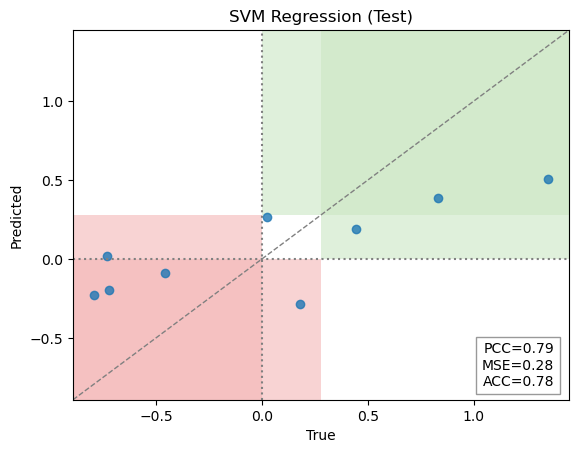

TRAIN (OOF, seq-level): {'MSE': 0.7546603456129435, 'PCC': 0.13572262146076208, 'ACC': 0.6060606060606061}
TEST  (seq-level):      {'MSE': 0.2826152770556806, 'PCC': 0.7932099865139398, 'ACC': 0.7777777777777778}


In [108]:
# Fit scaler on full train, eval on test (this is Carmen’s right panel)
sc_full = StandardScaler().fit(X_train.values)
X_train_s = sc_full.transform(X_train.values)
X_test_s  = sc_full.transform(X_test.values)

svr_full = SVR(kernel="rbf", C=1.81, gamma=0.004, epsilon=0.1)
svr_full.fit(X_train_s, y_train.values)

yhat_test = svr_full.predict(X_test_s)

test_seq = seq_aggregate(y_test.values, yhat_test, df_test_avg[ID_COL].values)
test_metrics = metrics_seq_level(test_seq["y_true"], test_seq["y_pred"])
test_box = f"PCC={test_metrics['PCC']:.2f}\nMSE={test_metrics['MSE']:.2f}\nACC={test_metrics['ACC']:.2f}"
plot_carmen_panel(test_seq["y_true"], test_seq["y_pred"], "SVM Regression (Test)", test_box)

print("TRAIN (OOF, seq-level):", train_metrics)
print("TEST  (seq-level):     ", test_metrics)


Raw data (all frames per sequence)
   ↓
GroupShuffleSplit (train/test)
   ↓
keep_last_n_percent (KEEP_LAST_PCT=100 for regression)
   ↓
average_in_chunks_per_sequence (NAVG=20)
   ↓
SVM training on *per-frame* data (NOT per-sequence averages)
   ↓
Then sequence-averaging applied again only for final scatter plots.


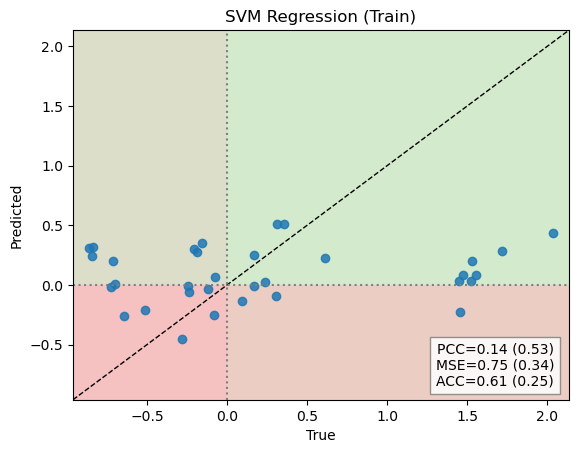

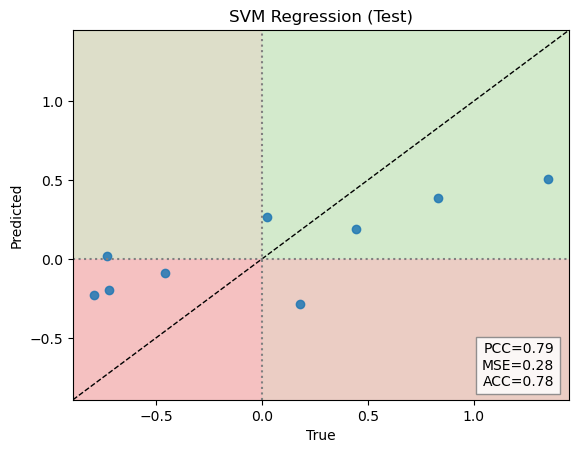

CV mean  (seq-level): {'MSE': '0.74', 'PCC': '0.23', 'ACC': '0.61'}
CV std   (seq-level): {'MSE': '0.34', 'PCC': '0.53', 'ACC': '0.25'}
TRAIN OOF(seq-level): {'MSE': 0.7546603456129435, 'PCC': 0.13572262146076208, 'ACC': 0.6060606060606061}
TEST     (seq-level): {'MSE': 0.2826152770556806, 'PCC': 0.7932099865139398, 'ACC': 0.7777777777777778}


In [109]:
from sklearn.model_selection import GroupKFold
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_SCALE = "log"
THR = 0.0 if DATA_SCALE == "log" else 1.0

def seq_aggregate(y_true, y_pred, seq_ids):
    d = {}
    for t,p,s in zip(y_true, y_pred, seq_ids):
        d.setdefault(s, {"t":[], "p":[]})
        d[s]["t"].append(float(t)); d[s]["p"].append(float(p))
    return pd.DataFrame({
        "sequence": list(d.keys()),
        "y_true":   [np.mean(v["t"]) for v in d.values()],
        "y_pred":   [np.mean(v["p"]) for v in d.values()],
    })

def metrics_seq_level(y_true_seq, y_pred_seq):
    mse = mean_squared_error(y_true_seq, y_pred_seq)
    pcc = pearsonr(y_true_seq, y_pred_seq)[0] if len(y_true_seq) > 1 else np.nan
    acc = accuracy_score((y_true_seq>THR).astype(int), (y_pred_seq>THR).astype(int))
    return {"MSE": mse, "PCC": pcc, "ACC": acc}

def plot_panel(y_true_seq, y_pred_seq, title, box_text):
    x, y = np.asarray(y_true_seq), np.asarray(y_pred_seq)
    lo = min(x.min(), y.min()) - 0.1
    hi = max(x.max(), y.max()) + 0.1
    fig, ax = plt.subplots()
    ax.axvspan(lo, THR, facecolor="#f4b6b6", alpha=0.6); ax.axvspan(THR, hi, facecolor="#cbe7c3", alpha=0.6)
    ax.axhspan(lo, THR, facecolor="#f4b6b6", alpha=0.6); ax.axhspan(THR, hi, facecolor="#cbe7c3", alpha=0.6)
    ax.scatter(x, y, alpha=0.85)
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.axvline(THR, color="gray", ls=":"); ax.axhline(THR, color="gray", ls=":")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("True"); ax.set_ylabel("Predicted"); ax.set_title(title)
    ax.text(0.97, 0.03, box_text, transform=ax.transAxes, ha="right", va="bottom",
            bbox=dict(facecolor="white", edgecolor="gray", alpha=0.85))
    plt.show()

# ===== 5-fold OOF on TRAIN =====
groups_tr = df_train_avg[ID_COL].values
Xtr_raw = X_train.values
ytr     = y_train.values

gkf = GroupKFold(n_splits=5)
oof_pred = np.empty_like(ytr, dtype=float)
fold_metrics = []

for fold, (tr, va) in enumerate(gkf.split(Xtr_raw, ytr, groups=groups_tr), 1):
    # scale on fold-train only
    sc = StandardScaler().fit(Xtr_raw[tr])
    X_tr_s = sc.transform(Xtr_raw[tr])
    X_va_s = sc.transform(Xtr_raw[va])

    svr = SVR(kernel="rbf", C=1.81, gamma=0.004, epsilon=0.1)
    svr.fit(X_tr_s, ytr[tr])

    va_pred = svr.predict(X_va_s)
    oof_pred[va] = va_pred

    va_seq = seq_aggregate(ytr[va], va_pred, groups_tr[va])
    fold_metrics.append(metrics_seq_level(va_seq["y_true"], va_seq["y_pred"]))

cv_mean = {k: float(np.mean([m[k] for m in fold_metrics])) for k in fold_metrics[0]}
cv_std  = {k: float(np.std ([m[k] for m in fold_metrics], ddof=1)) for k in fold_metrics[0]}

train_seq_oof = seq_aggregate(ytr, oof_pred, groups_tr)
train_metrics = metrics_seq_level(train_seq_oof["y_true"], train_seq_oof["y_pred"])
train_box = f"PCC={train_metrics['PCC']:.2f} ({cv_std['PCC']:.2f})\n" \
            f"MSE={train_metrics['MSE']:.2f} ({cv_std['MSE']:.2f})\n" \
            f"ACC={train_metrics['ACC']:.2f} ({cv_std['ACC']:.2f})"
plot_panel(train_seq_oof["y_true"], train_seq_oof["y_pred"], "SVM Regression (Train)", train_box)

# ===== Fit full TRAIN, evaluate on TEST =====
sc_full = StandardScaler().fit(X_train.values)
X_train_s = sc_full.transform(X_train.values)
X_test_s  = sc_full.transform(X_test.values)

svr_full = SVR(kernel="rbf", C=1.81, gamma=0.004, epsilon=0.1)
svr_full.fit(X_train_s, y_train.values)

yhat_test = svr_full.predict(X_test_s)
test_seq = seq_aggregate(y_test.values, yhat_test, df_test_avg[ID_COL].values)
test_metrics = metrics_seq_level(test_seq["y_true"], test_seq["y_pred"])
test_box = f"PCC={test_metrics['PCC']:.2f}\nMSE={test_metrics['MSE']:.2f}\nACC={test_metrics['ACC']:.2f}"
plot_panel(test_seq["y_true"], test_seq["y_pred"], "SVM Regression (Test)", test_box)

print("CV mean  (seq-level):", {k: f"{cv_mean[k]:.2f}" for k in cv_mean})
print("CV std   (seq-level):", {k: f"{cv_std[k]:.2f}"  for k in cv_std})
print("TRAIN OOF(seq-level):", train_metrics)
print("TEST     (seq-level):", test_metrics)
